In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math

In [ ]:
# Quick check
dl = get_data()
xb, yb = next(iter(dl))
print(f"Batch shape: {xb.shape}")

Dataset root: data\kaggle_room_street_data
Train batch shape: torch.Size([128, 3, 64, 64])
Classes: ['house_data', 'street_data']
Batch shape: torch.Size([128, 3, 64, 64])


In [79]:
def get_data(batch_size=128, image_size=64, data_root="data/kaggle_room_street_data"):
    from pathlib import Path
    from torchvision.datasets import ImageFolder
    from torch.utils.data import random_split
    from torch.utils.data import Subset

    kaggle_dir = Path(data_root)
    kaggle_dir.mkdir(parents=True, exist_ok=True)

    # Download and unzip the dataset once if it is not already present
    if not any(kaggle_dir.rglob("*.jpg")) and not any(kaggle_dir.rglob("*.png")):
        raise FileNotFoundError(
            f"No images found in {kaggle_dir}. Please download the dataset from Kaggle and place it in this directory."
        )

    # Try to locate the folder structure expected by ImageFolder
    candidate_roots = [
        p for p in [kaggle_dir, *kaggle_dir.rglob("*")]
        if p.is_dir() and any(child.is_dir() for child in p.iterdir())
    ]
    dataset_root = candidate_roots[0] if candidate_roots else kaggle_dir

    rgb_tfs = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    full_ds = ImageFolder(root=str(dataset_root), transform=rgb_tfs)
    target_idx = full_ds.class_to_idx['street_data']
    indices = [i for i, (_, l) in enumerate(full_ds.samples) if l == target_idx]
    train_ds = Subset(full_ds, indices)
    
    # train_len = int(0.9 * len(full_ds))
    # val_len = len(full_ds) - train_len
    # train_ds, val_ds = random_split(
    #     full_ds,
    #     [train_len, val_len],
    #     generator=torch.Generator().manual_seed(42),
    # )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    # val_loader = DataLoader(
    #     val_ds,
    #     batch_size=batch_size,
    #     shuffle=False,
    #     num_workers=2,
    #     pin_memory=torch.cuda.is_available(),
    # )

    xb_rgb, yb_rgb = next(iter(train_loader))
    print(f"Dataset root: {dataset_root}")
    print(f"Train batch shape: {xb_rgb.shape}")
    print(f"Classes: {full_ds.classes}")
    return train_loader #, val_loader


In [31]:
class DiffusionScheduler:
    def __init__(self, steps=1000, beta_start=1e-4, beta_end=0.005):
        self.steps = steps
        
        # 1. Define a linear schedule for beta (noise variance)
        self.betas = torch.linspace(beta_start, beta_end, steps)
        
        # 2. Precompute alpha values
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        
        # 3. Precompute square roots for the forward sampling formula
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

    def add_noise(self, x_0, t):
        """
        Noisify a batch of images x_0 at specific timesteps t.
        """
        device = x_0.device
        noise = torch.randn_like(x_0)
        
        # Grab the constants for the specific timesteps t
        # We reshape to [batch, 1, 1, 1] for broadcasting
        sqrt_alpha_bar = self.sqrt_alphas_cumprod.to(device)[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alphas_cumprod.to(device)[t].view(-1, 1, 1, 1)
        
        # The core formula:
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
        
        return x_t, noise

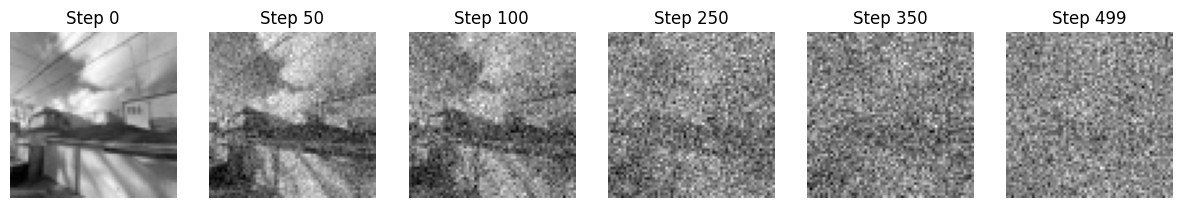

In [89]:
STEPS = 500
BETA_END = 0.005

scheduler = DiffusionScheduler(steps=STEPS, beta_end=BETA_END)
# Pick a sample image from our batch
img = xb[2] 

# Visualize progress at different timesteps
# steps = [0, 50, 100, 250, 500, 699, 999]
steps = [0, 50, 100, 250, 350, 499]
plt.figure(figsize=(15, 3))

for i, t in enumerate(steps):
    t_tensor = torch.tensor([t])
    noisy_img, _ = scheduler.add_noise(img, t_tensor)
    
    plt.subplot(1, len(steps), i+1)
    # Denormalize from [-1, 1] back to [0, 1] for plotting
    plt.imshow(noisy_img[0][0] * 0.5 + 0.5, cmap="gray")
    plt.title(f"Step {t}")
    plt.axis("off")

plt.show()

In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [6]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, groups=8):
        super().__init__()
        # Time projection to match feature map channels
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels * 2) # Multiply by 2 for scale and shift
        )
        
        self.conv1 = nn.Sequential(
            nn.GroupNorm(groups, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        )
        
        self.conv2 = nn.Sequential(
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        )

        self.res_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t):
        # 1. First convolution
        h = self.conv1(x)
        
        # 2. Integrate Time Embedding (Scale and Shift)
        t_emb = self.mlp(t).unsqueeze(-1).unsqueeze(-1)
        scale, shift = t_emb.chunk(2, dim=1)
        h = h * (scale + 1) + shift
        
        # 3. Second convolution
        h = self.conv2(h)
        
        # 4. Residual connection
        return h + self.res_conv(x)

In [7]:
# Debugged
# Changes applied: in the UNet `ups` construction, ensure the ResBlock `in_channels`
# matches the concatenated channels (upsampled + skip) and the ConvTranspose2d
# uses the previous `channels` as its `in_channels`.
# Snippet of the applied change (for reference):
# for mult in reversed(ch_mults):
#     out_c = base_ch * mult
#     self.ups.append(nn.ModuleDict({
#         'block': ResBlock(out_c * 2, out_c, time_dim),
#         'up': nn.ConvTranspose2d(channels, out_c, 4, 2, 1),
#     }))
#     channels = out_c

In [8]:
class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base_ch=64, ch_mults=(1, 2, 4, 8)):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_ch),
            nn.Linear(base_ch, base_ch * 4),
            nn.SiLU(),
            nn.Linear(base_ch * 4, base_ch * 4)
        )
        time_dim = base_ch * 4

        self.init_conv = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)
        
        # Downsampling path
        self.downs = nn.ModuleList([])
        channels = base_ch
        for mult in ch_mults:
            out_c = base_ch * mult
            self.downs.append(nn.ModuleDict({
                'block': ResBlock(channels, out_c, time_dim),
                'down': nn.Conv2d(out_c, out_c, 4, 2, 1) # Downsample via stride
            }))
            channels = out_c

        # Middle block
        self.mid_block = ResBlock(channels, channels, time_dim)

        # Upsampling path
        self.ups = nn.ModuleList([])
        for mult in reversed(ch_mults):
            out_c = base_ch * mult
            self.ups.append(nn.ModuleDict({
                'block': ResBlock(out_c * 2, out_c, time_dim),
                'up': nn.ConvTranspose2d(channels, out_c, 4, 2, 1),
            }))
            channels = out_c

        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, out_ch, 3, padding=1)
        )

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.init_conv(x)
        
        # Down
        skip_conns = []
        for down in self.downs:
            x = down['block'](x, t)
            skip_conns.append(x)
            x = down['down'](x)
            
        # Mid
        x = self.mid_block(x, t)
        
        # Up
        for up in self.ups:
            x = up['up'](x)
            skip = skip_conns.pop()
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = torch.cat((x, skip), dim=1) # Concatenate skip connection
            x = up['block'](x, t)
            
        return self.final_conv(x)

In [90]:
# Hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"
epochs = 10
lr = 1e-4
batch_size = 128
steps = STEPS
beta_end = BETA_END

# Initialize our components
model = UNet(in_ch=3, out_ch=3, base_ch=64).to(device) # 1 channel for Fashion-MNIST
scheduler = DiffusionScheduler(steps=steps, beta_end=beta_end)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
train_loader = get_data(batch_size=batch_size)

print(f"Training on {device}...")
model.train()



for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # 1. Sample random timesteps for each image in the batch
        t = torch.randint(0, scheduler.steps, (images.shape[0],), device=device).long()
        
        # 2. Add noise to the images using the scheduler
        # x_t is the noisy image, noise is the 'target' we want to predict
        x_t, noise = scheduler.add_noise(images, t)
        
        # 3. Predict the noise using the U-Net
        predicted_noise = model(x_t, t)
        
        # 4. Calculate Loss (How close was the prediction to the actual noise?)
        loss = criterion(predicted_noise, noise)
        
        # 5. Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Avg Loss: {avg_loss:.4f}")

Dataset root: data\kaggle_room_street_data
Train batch shape: torch.Size([128, 3, 64, 64])
Classes: ['house_data', 'street_data']
Training on cuda...
Epoch [1/10] | Avg Loss: 0.2441
Epoch [2/10] | Avg Loss: 0.1040
Epoch [3/10] | Avg Loss: 0.0874
Epoch [4/10] | Avg Loss: 0.0775
Epoch [5/10] | Avg Loss: 0.0721
Epoch [6/10] | Avg Loss: 0.0683
Epoch [7/10] | Avg Loss: 0.0652
Epoch [8/10] | Avg Loss: 0.0641
Epoch [9/10] | Avg Loss: 0.0606
Epoch [10/10] | Avg Loss: 0.0621


In [100]:
@torch.no_grad()
def denoise(model, scheduler, x, start_t=None):
    model.eval()

    if start_t is None:
        start_t = scheduler.steps // 2

    batch_size = x.shape[0]
    t = torch.full((batch_size,), start_t, device=x.device, dtype=torch.long)
    noisy_x, _ = scheduler.add_noise(x, t)

    # Reverse the diffusion process from the chosen noisy timestep back to 0
    for i in reversed(range(start_t + 1)):
        t = torch.full((batch_size,), i, device=x.device, dtype=torch.long)
        predicted_noise = model(noisy_x, t)

        alpha = scheduler.alphas[i].to(x.device)
        alpha_cumprod = scheduler.alphas_cumprod[i].to(x.device)
        beta = scheduler.betas[i].to(x.device)

        if i > 0:
            noise = torch.randn_like(noisy_x)
        else:
            noise = 0

        noisy_x = (1 / torch.sqrt(alpha)) * (
            noisy_x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    return noisy_x

start_t = STEPS - 100
# Denoise some real Fashion-MNIST clothes
base_batch, _ = next(iter(train_loader))
base_batch = base_batch[:16].to(device)
denoised_samples = denoise(model, scheduler, base_batch, start_t=start_t)


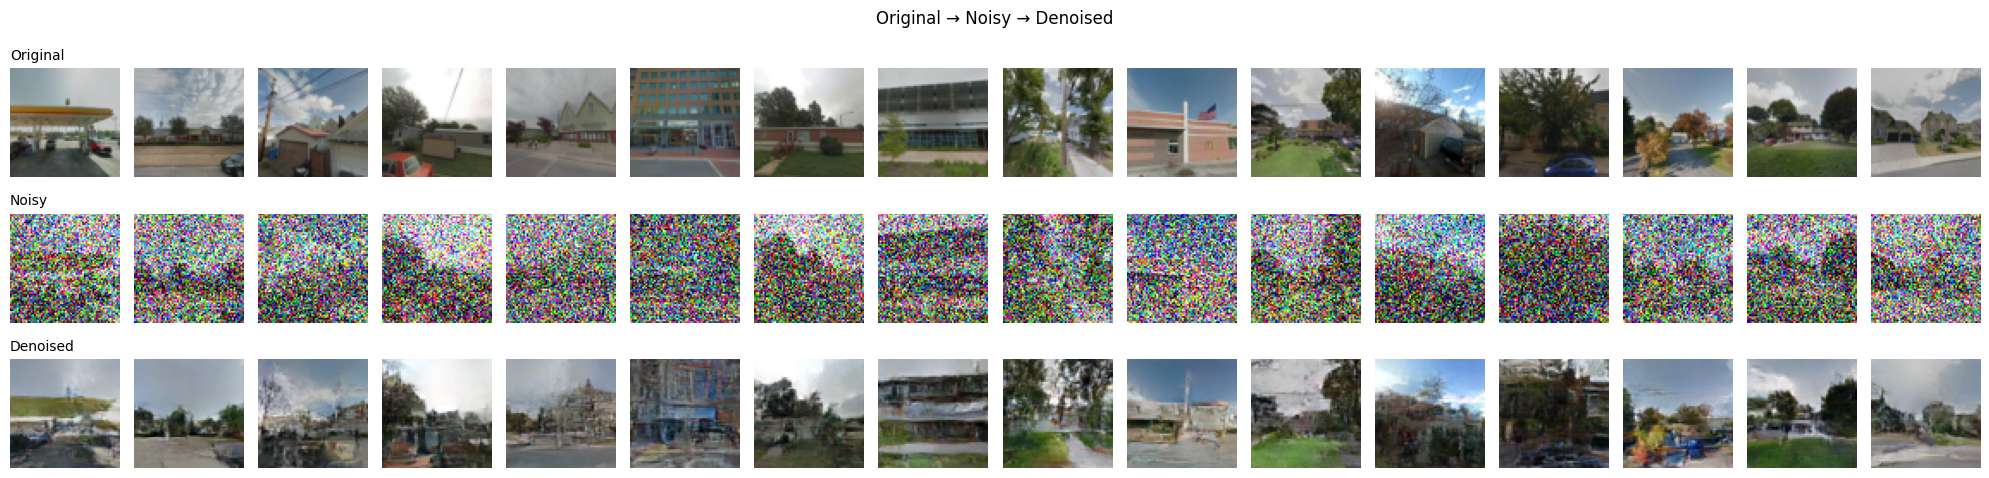

In [101]:
# Visualization: Original â†’ Noisy â†’ Denoised (supports grayscale or RGB)
base_vis = base_batch.detach().cpu()

# Add noise to the same real images at the chosen timestep
noisy_t = torch.full((base_vis.shape[0],), start_t, device=base_batch.device, dtype=torch.long)
noisy_batch, _ = scheduler.add_noise(base_batch.to(base_batch.device), noisy_t)
noisy_vis = noisy_batch.detach().cpu()

denoised_vis = denoised_samples.detach().cpu()

B, C, H, W = base_vis.shape
n = min(16, B)
fig, axes = plt.subplots(3, n, figsize=(20, 5))

rows = [(base_vis, "Original"), (noisy_vis, "Noisy"), (denoised_vis, "Denoised")]
for r, (imgs, title) in enumerate(rows):
    for i in range(n):
        img = imgs[i]
        if C == 1:
            disp = (img[0] * 0.5 + 0.5).clamp(0, 1)
            axes[r, i].imshow(disp, cmap='gray')
        else:
            disp = (img.permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1)
            axes[r, i].imshow(disp)
        axes[r, i].axis('off')
        if i == 0:
            axes[r, i].set_title(title, loc='left', fontsize=10)

plt.suptitle("Original â†’ Noisy â†’ Denoised")
plt.tight_layout()
plt.show()


In [95]:
continue_epochs = 10

print(f"Continue Training by {continue_epochs} epochs...")
for epoch in range(continue_epochs):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # 1. Sample random timesteps for each image in the batch
        t = torch.randint(0, scheduler.steps, (images.shape[0],), device=device).long()
        
        # 2. Add noise to the images using the scheduler
        # x_t is the noisy image, noise is the 'target' we want to predict
        x_t, noise = scheduler.add_noise(images, t)
        
        # 3. Predict the noise using the U-Net
        predicted_noise = model(x_t, t)
        
        # 4. Calculate Loss (How close was the prediction to the actual noise?)
        loss = criterion(predicted_noise, noise)
        
        # 5. Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epochs + epoch + 1}/{epochs + continue_epochs}] | Avg Loss: {avg_loss:.4f}")

epochs += continue_epochs

Continue Training by 10 epochs...
Epoch [11/20] | Avg Loss: 0.0605
Epoch [12/20] | Avg Loss: 0.0595
Epoch [13/20] | Avg Loss: 0.0582
Epoch [14/20] | Avg Loss: 0.0585
Epoch [15/20] | Avg Loss: 0.0584
Epoch [16/20] | Avg Loss: 0.0567
Epoch [17/20] | Avg Loss: 0.0556
Epoch [18/20] | Avg Loss: 0.0564
Epoch [19/20] | Avg Loss: 0.0561
Epoch [20/20] | Avg Loss: 0.0555


In [ ]:

# Save the trained model
import os

# Create a models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model state dict (weights only - recommended)
model_path = "models/diffusion_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Optional: Also save the full model (less recommended, but possible)
# full_model_path = "models/diffusion_model_full.pt"
# torch.save(model, full_model_path)
# print(f"Full model saved to {full_model_path}")

# To load the model later, use:
# model = UNet(in_ch=1, out_ch=1, base_ch=64).to(device)
# model.load_state_dict(torch.load("models/diffusion_model.pth"))
# model.eval()


Model saved to models/diffusion_model_street.pth


In [ ]:
# --- Feature 1: Faster Sampling (DDIM) ---
# Generates an image in a fraction of the steps (e.g. 50 instead of 1000)
import torch

def sample_ddim(model, scheduler, image_size=64, ddim_steps=50):
    model.eval()
    device = next(model.parameters()).device
    
    step_size = scheduler.steps // ddim_steps
    timesteps = list(range(0, scheduler.steps, step_size))[::-1]
    
    x_t = torch.randn(1, 3, image_size, image_size, device=device)
    
    with torch.no_grad():
        for i in range(len(timesteps)):
            t = timesteps[i]
            t_tensor = torch.tensor([t], device=device)
            
            alpha_prod_t = scheduler.alphas_cumprod[t]
            
            t_prev = timesteps[i+1] if i < len(timesteps) - 1 else -1
            if t_prev >= 0:
                alpha_prod_t_prev = scheduler.alphas_cumprod[t_prev]
            else:
                alpha_prod_t_prev = torch.tensor(1.0, device=device)
            
            predicted_noise = model(x_t, t_tensor)
            pred_x0 = (x_t - torch.sqrt(1 - alpha_prod_t) * predicted_noise) / torch.sqrt(alpha_prod_t)
            dir_xt = torch.sqrt(1 - alpha_prod_t_prev) * predicted_noise
            x_t = torch.sqrt(alpha_prod_t_prev) * pred_x0 + dir_xt
            
    x_t = (x_t.clamp(-1, 1) + 1) / 2
    return x_t


In [ ]:
# --- Feature 2: Image-to-Image (SDEdit) ---
# Modifies an existing image based on a strength parameter (0.0 to 1.0)
import torch

def image_to_image(model, scheduler, init_image, strength=0.5):
    model.eval()
    device = init_image.device
    
    start_step = int(scheduler.steps * strength) - 1
    noise = torch.randn_like(init_image)
    alpha_cumprod = scheduler.alphas_cumprod[start_step]
    
    x_t = torch.sqrt(alpha_cumprod) * init_image + torch.sqrt(1 - alpha_cumprod) * noise
    
    with torch.no_grad():
        for i in reversed(range(start_step + 1)):
            t_tensor = torch.tensor([i], device=device)
            predicted_noise = model(x_t, t_tensor)
            
            alpha = scheduler.alphas[i]
            alpha_prod = scheduler.alphas_cumprod[i]
            beta = scheduler.betas[i]
            
            if i > 0:
                random_noise = torch.randn_like(x_t)
            else:
                random_noise = torch.zeros_like(x_t)
                
            noise_factor = (1 - alpha) / torch.sqrt(1 - alpha_prod)
            x_t = (1 / torch.sqrt(alpha)) * (x_t - noise_factor * predicted_noise) + torch.sqrt(beta) * random_noise
            
    x_t = (x_t.clamp(-1, 1) + 1) / 2
    return x_t


In [ ]:
# --- Feature 3: Image Inpainting ---
# Fills in masked regions (mask=0) while keeping unmasked regions (mask=1) intact
import torch

def inpaint(model, scheduler, init_image, mask):
    # init_image: [1, 3, 64, 64] scaled between [-1, 1]
    # mask: [1, 1, 64, 64] where 1 is "keep" and 0 is "replace"
    model.eval()
    device = init_image.device
    
    # Start from pure noise for the inpainted regions
    x_t = torch.randn_like(init_image)
    
    with torch.no_grad():
        for i in reversed(range(scheduler.steps)):
            t_tensor = torch.tensor([i], device=device)
            
            # Forward diffuse the REAL image to step i
            alpha_cumprod = scheduler.alphas_cumprod[i]
            noise = torch.randn_like(init_image)
            real_x_t = torch.sqrt(alpha_cumprod) * init_image + torch.sqrt(1 - alpha_cumprod) * noise
            
            # Force the unmasked regions to be exactly the real noisy image
            x_t = real_x_t * mask + x_t * (1 - mask)
            
            # Predict noise
            predicted_noise = model(x_t, t_tensor)
            
            # Standard DDPM reverse step
            alpha = scheduler.alphas[i]
            alpha_prod = scheduler.alphas_cumprod[i]
            beta = scheduler.betas[i]
            
            if i > 0:
                random_noise = torch.randn_like(x_t)
            else:
                random_noise = torch.zeros_like(x_t)
                
            noise_factor = (1 - alpha) / torch.sqrt(1 - alpha_prod)
            x_t = (1 / torch.sqrt(alpha)) * (x_t - noise_factor * predicted_noise) + torch.sqrt(beta) * random_noise
            
    # Final merge to ensure perfect edges
    x_0 = init_image * mask + x_t * (1 - mask)
    x_0 = (x_0.clamp(-1, 1) + 1) / 2
    return x_0


In [ ]:
# --- Example Usage ---
# import matplotlib.pyplot as plt

# 1. Faster DDIM Sampling (Takes seconds instead of minutes)
# fast_img = sample_ddim(model, scheduler, ddim_steps=50)
# plt.imshow(fast_img[0].permute(1, 2, 0).cpu().numpy())
# plt.title("50-Step DDIM")
# plt.show()

# 2. Image-to-Image Translation
# batch = next(iter(train_loader))[0].to(device)
# original_image = batch[0:1] # Get first image in batch
# itoi_img = image_to_image(model, scheduler, original_image, strength=0.6)
# plt.imshow(itoi_img[0].permute(1, 2, 0).cpu().numpy())
# plt.title("Image-to-Image (Strength 0.6)")
# plt.show()

# 3. Inpainting
# mask = torch.ones(1, 1, 64, 64).to(device)
# mask[:, :, 20:44, 20:44] = 0 # Blank out a 24x24 square in the middle
# inpainted_img = inpaint(model, scheduler, original_image, mask)
# plt.imshow(inpainted_img[0].permute(1, 2, 0).cpu().numpy())
# plt.title("Inpainted Image")
# plt.show()
